<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week07_grover_unstructured_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies
!pip install qiskit qiskit-aer matplotlib pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00


In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit_aer import StatevectorSimulator

### Grover Search Parameters
We work with $n = 4$ qubits, so the search space has $N = 2^4 = 16$ elements.
The marked state is $x^\star = 1101$ (matching the example from the lecture notes). You can change it to any other basis state in the code cell below.

**Note**: Qiskit uses ***little-endian*** bit ordering, so the string is reversed when passed to the circuit — we handle this explicitly below.

In [3]:
# Parameters
n = 4                    # number of qubits
N = 2**n                 # search space size: 16
marked = '1101'          # the state we want to find (big-endian, as in the notes)

# Optimal number of Grover iterations
k_opt = round((np.pi / 4) * np.sqrt(N) - 0.5) #value of k from the notes
print(f"Search space size N = {N}")
print(f"Unique marked state: |{marked}⟩")
print(f"Optimal number of Grover iterations: k = {k_opt}")

Search space size N = 16
Unique marked state: |1101⟩
Optimal number of Grover iterations: k = 3


### The Phase Oracle Z_f
$Z_f$ flips the phase of $|x^\star\rangle$ and leaves all other states unchanged.

Circuit recipe for marking an arbitrary state $|t\rangle$:
1. Apply Pauli-$X$ gate to every qubit where $t$ has a $0$  -- so $|t\rangle$ maps to $|1111\rangle$.
2. Apply a multi-controlled-$Z$  (MCZ) — phases $|1111\rangle$ by $-1$
3. Undo the X gates from step 1

The multi-controlled-$Z$ is implemented as: $H$ on target qubit $\to$ multi-controlled-$X$ $\to$ $H$.

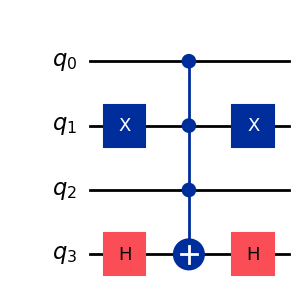

In [7]:
# Phase oracle
def phase_oracle(n, marked_state):
    """
    Returns a QuantumCircuit that implements Z_f for the given marked_state string.
    marked_state: big-endian binary string, e.g. '1101'
    """
    qc = QuantumCircuit(n, name='$Z_f$')

    # Qiskit is little-endian: qubit 0 is the rightmost bit.
    # Reverse the string so index 0 matches the rightmost character.
    target = marked_state[::-1]

    # Flip qubits where target bit is '0'
    for i, bit in enumerate(target):
        if bit == '0':
            qc.x(i)
    # Multi-controlled-Z via H + MCX + H on the last qubit
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)   # multi-controlled-X
    qc.h(n - 1)
    # Undo the X flips
    for i, bit in enumerate(target):
        if bit == '0':
            qc.x(i)
    return qc

oracle = phase_oracle(n, marked)
oracle.draw('mpl', style='iqp')

### The Diffusion Operator $D = 2|s\rangle\langle s| - I$
$D$ reflects amplitudes about the mean. Its circuit decomposition is:

$$D = H^{\otimes n} (2|0\rangle\langle 0| - I) H^{\otimes n},$$

where $(2|0\rangle\langle 0| - I)$ flips the phase of everything *except* |00...0⟩, and is implemented as: $$X^{\otimes n} \to \text{MCZ} \to X^{\otimes n}.$$

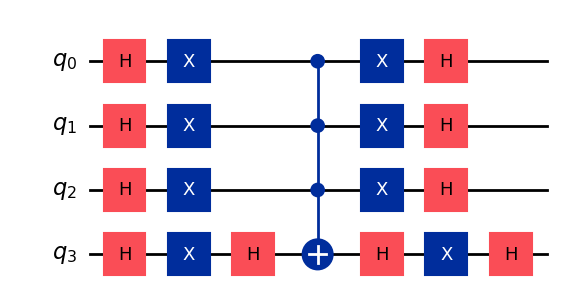

In [8]:
# Diffusion operator
def diffusion_operator(n):
    """
    Returns a QuantumCircuit implementing D = 2|s><s| - I.
    """
    qc = QuantumCircuit(n, name='D')

    # H to the nth tensor power
    qc.h(range(n))
    # 2|0><0| - I: flip phase of all states except all zeroes
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))

    # H to the nth tensor power
    qc.h(range(n))

    return qc

diffuser = diffusion_operator(n)
diffuser.draw('mpl', style='iqp')

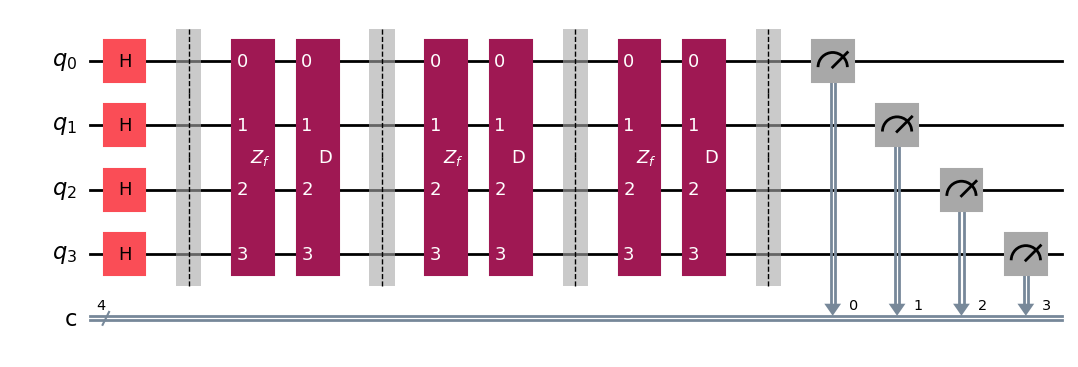

In [9]:
# The Full Grover circuit
def grover_circuit(n, marked_state, iterations):
    """
    Builds the full Grover circuit for the given number of iterations.
    """
    qc = QuantumCircuit(n, n)

    # Step 0: uniform superposition
    qc.h(range(n))
    qc.barrier()

    # Grover iterations
    oracle = phase_oracle(n, marked_state)
    diffuser = diffusion_operator(n)

    for i in range(iterations):
        qc.append(oracle.to_gate(), range(n))
        qc.append(diffuser.to_gate(), range(n))
        qc.barrier()

    # Measure
    qc.measure(range(n), range(n))
    return qc

qc = grover_circuit(n, marked, k_opt) #experiment with k_opt
qc.draw('mpl', style='iqp', fold=40)

Measurement results (2048 shots):
{'0000': 3, '1110': 5, '1101': 1951, '1010': 4, '0001': 11, '1111': 4, '0100': 6, '0010': 5, '0111': 3, '0011': 6, '1011': 9, '1100': 6, '0110': 10, '1000': 6, '1001': 13, '0101': 6}


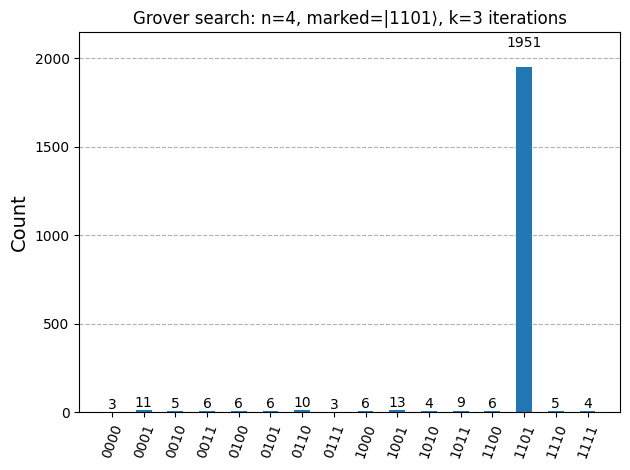

In [10]:
# Simulate and plot results
simulator = AerSimulator()
shots = 2048

tqc = transpile(qc, simulator)
result = simulator.run(tqc, shots=shots).result()
counts = result.get_counts()

print(f"Measurement results ({shots} shots):")
print(counts)

plot_histogram(counts, title=f"Grover search: n=4, marked=|{marked}⟩, k={k_opt} iterations")

### Change $k$ and re-run the circuit
Change the value of $k=1,2,3,4,5$ and re-run the Grover circuit. The probability of measuring the marked state should peak at $k=3$, and you should see it drop for $k=4$, exactly the *overshooting* effect we discussed in the notes.  

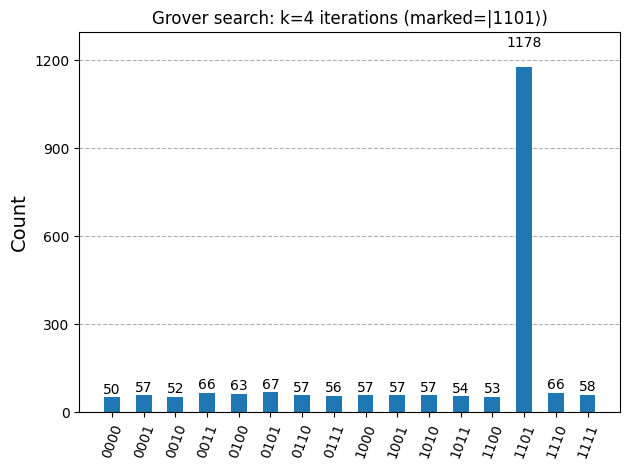

In [11]:
# Experiment with different iteration counts
k = 4 # <-- change this and re-run
qc_exp = grover_circuit(n, marked, iterations=k)
tqc_exp = transpile(qc_exp, simulator)
counts_exp = simulator.run(tqc_exp, shots=2048).result().get_counts()

plot_histogram(counts_exp, title=f"Grover search: k={k} iterations (marked=|{marked}⟩)")